Loading cleaned data and setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load cleaned data
X = np.load('bragg_signals_cleaned.npy')
y = np.load('bragg_labels.npy')

depth = np.linspace(0, 30, 300)

print(f"Loaded: {X.shape[0]} signals, {X.shape[1]} points each")
print(f"Labels: {np.unique(y)}")

Loaded: 6000 signals, 300 points each
Labels: ['amplitude_drop' 'missing_peak' 'normal' 'range_shift' 'scatter_artifact']


Extract Features for ONE Signal

In [3]:
def extract_features(signal, depth):
    features = {}

    # ── FEATURE 1: Peak Position ──────────────────────────────
    # At what depth (cm) does the maximum energy appear?
    peak_idx = np.argmax(signal)
    features['peak_position'] = depth[peak_idx]

    # ── FEATURE 2: Peak Height ────────────────────────────────
    # What is the maximum energy value? (after normalization, 0–1)
    features['peak_height'] = signal[peak_idx]

    # ── FEATURE 3: Peak Width (FWHM) ─────────────────────────
    # FWHM = Full Width at Half Maximum
    # How wide is the peak at half its height?
    # Narrow = sharp beam (good), Wide = scattered beam (bad)
    half_max = features['peak_height'] / 2
    above_half = signal >= half_max
    
    if above_half.sum() > 1:
        left_idx  = np.argmax(above_half)               # first point above half
        right_idx = len(above_half) - np.argmax(above_half[::-1]) - 1  # last point
        features['peak_width_fwhm'] = depth[right_idx] - depth[left_idx]
    else:
        features['peak_width_fwhm'] = 0.0

    # ── FEATURE 4: Area Under Curve ──────────────────────────
    # Total energy delivered across the full depth
    # np.trapz = numerical integration (area under curve)
    features['total_area'] = np.trapz(signal, depth)

    # ── FEATURE 5: Entrance Area vs Peak Area ─────────────────
    # Split signal at peak position
    # Before peak = entrance region, After peak = tail region
    entrance_signal = signal[:peak_idx]
    tail_signal     = signal[peak_idx:]

    features['entrance_area'] = np.trapz(entrance_signal, depth[:peak_idx]) if peak_idx > 0 else 0
    features['tail_area']     = np.trapz(tail_signal,     depth[peak_idx:])

    # ── FEATURE 6: Entrance-to-Peak Ratio ────────────────────
    # Low ratio = most energy at peak (good)
    # High ratio = energy spread throughout (bad, like missing peak)
    if features['peak_height'] > 0:
        features['entrance_to_peak_ratio'] = features['entrance_area'] / (features['total_area'] + 1e-9)
    else:
        features['entrance_to_peak_ratio'] = 1.0

    # ── FEATURE 7: Signal Slope Before Peak ──────────────────
    # How steeply does the signal rise toward the peak?
    # Range shift = peak rises at wrong location
    if peak_idx > 5:
        rise_region = signal[peak_idx-5 : peak_idx+1]
        features['pre_peak_slope'] = (rise_region[-1] - rise_region[0]) / 5
    else:
        features['pre_peak_slope'] = 0.0

    # ── FEATURE 8: Signal Slope After Peak ───────────────────
    # How steeply does it drop after the peak?
    if peak_idx < len(signal) - 5:
        fall_region = signal[peak_idx : peak_idx+6]
        features['post_peak_slope'] = (fall_region[-1] - fall_region[0]) / 5
    else:
        features['post_peak_slope'] = 0.0

    # ── FEATURE 9: Signal Mean & Std ─────────────────────────
    # Overall statistics
    features['signal_mean'] = signal.mean()
    features['signal_std']  = signal.std()

    return features


# Test on ONE normal signal first
test_signal = X[0]
test_features = extract_features(test_signal, depth)

print("Features for Signal #0 (Normal):")
print("-" * 38)
for name, value in test_features.items():
    print(f"  {name:<25} : {value:.4f}")

Features for Signal #0 (Normal):
--------------------------------------
  peak_position             : 15.0502
  peak_height               : 1.0000
  peak_width_fwhm           : 2.2074
  total_area                : 5.2073
  entrance_area             : 3.2331
  tail_area                 : 1.8751
  entrance_to_peak_ratio    : 0.6209
  pre_peak_slope            : 0.0262
  post_peak_slope           : -0.0411
  signal_mean               : 0.1734
  signal_std                : 0.1948


In [5]:
Apply to All 6000 Signals

SyntaxError: invalid syntax (3929055212.py, line 1)

In [4]:
# Apply extract_features() to every signal
all_features = []

for i, signal in enumerate(X):
    f = extract_features(signal, depth)
    all_features.append(f)
    
    if (i + 1) % 1000 == 0:
        print(f"  Processed {i+1} / {len(X)} signals...")

# Convert list of dicts → DataFrame
df_features = pd.DataFrame(all_features)
df_features['label'] = y

print(f"\n✅ Feature extraction complete!")
print(f"   Shape: {df_features.shape}")
print(f"\nFirst 3 rows:")
print(df_features.head(3).round(3))

  Processed 1000 / 6000 signals...
  Processed 2000 / 6000 signals...
  Processed 3000 / 6000 signals...
  Processed 4000 / 6000 signals...
  Processed 5000 / 6000 signals...
  Processed 6000 / 6000 signals...

✅ Feature extraction complete!
   Shape: (6000, 12)

First 3 rows:
   peak_position  peak_height  peak_width_fwhm  total_area  entrance_area  \
0         15.050          1.0            2.207       5.207          3.233   
1         14.649          1.0            2.107       5.050          3.120   
2         14.247          1.0            2.007       4.791          2.780   

   tail_area  entrance_to_peak_ratio  pre_peak_slope  post_peak_slope  \
0      1.875                   0.621           0.026           -0.041   
1      1.831                   0.618           0.026           -0.033   
2      1.912                   0.580           0.046           -0.019   

   signal_mean  signal_std   label  
0        0.173       0.195  normal  
1        0.168       0.201  normal  
2        

 Visualize: Do Features Separate the Classes?

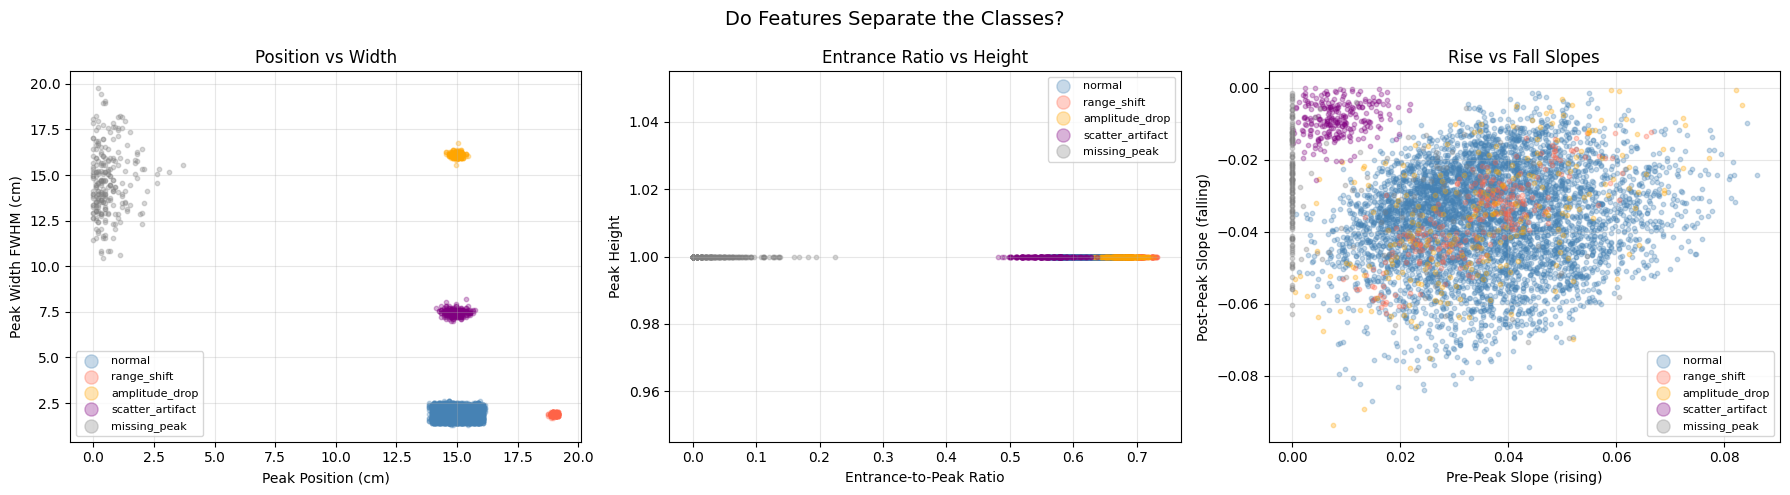

In [7]:
label_colors = {
    'normal':           'steelblue',
    'range_shift':      'tomato',
    'amplitude_drop':   'orange',
    'scatter_artifact': 'purple',
    'missing_peak':     'gray'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Do Features Separate the Classes?', fontsize=14)

# Plot 1: Peak Position vs Peak Width
ax = axes[0]
for label, color in label_colors.items():
    mask = df_features['label'] == label
    ax.scatter(
        df_features.loc[mask, 'peak_position'],
        df_features.loc[mask, 'peak_width_fwhm'],
        c=color, label=label, alpha=0.3, s=10
    )
ax.set_xlabel('Peak Position (cm)')
ax.set_ylabel('Peak Width FWHM (cm)')
ax.set_title('Position vs Width')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)

# Plot 2: Entrance Ratio vs Peak Height
ax = axes[1]
for label, color in label_colors.items():
    mask = df_features['label'] == label
    ax.scatter(
        df_features.loc[mask, 'entrance_to_peak_ratio'],
        df_features.loc[mask, 'peak_height'],
        c=color, label=label, alpha=0.3, s=10
    )
ax.set_xlabel('Entrance-to-Peak Ratio')
ax.set_ylabel('Peak Height')
ax.set_title('Entrance Ratio vs Height')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)

# Plot 3: Pre-slope vs Post-slope
ax = axes[2]
for label, color in label_colors.items():
    mask = df_features['label'] == label
    ax.scatter(
        df_features.loc[mask, 'pre_peak_slope'],
        df_features.loc[mask, 'post_peak_slope'],
        c=color, label=label, alpha=0.3, s=10
    )
ax.set_xlabel('Pre-Peak Slope (rising)')
ax.set_ylabel('Post-Peak Slope (falling)')
ax.set_title('Rise vs Fall Slopes')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

These graphs show how well your engineered features separate the different signal classes, and this is a very important step before building any machine learning model.

In the Position vs Width plot, you can clearly see strong separation between classes. The normal signals are tightly clustered around a peak position of about 15 cm with small width, while the range shift signals are clearly moved to a higher peak position. The amplitude drop signals stay near the same position but differ in width, and the scatter artifact signals have noticeably larger widths, forming a separate cluster. The missing peak signals are spread out and don’t form a clear peak position, making them easy to distinguish. This plot shows that peak position and width are very powerful features for classification.

In the Entrance Ratio vs Height plot, most classes have similar peak heights due to normalization, but the entrance-to-peak ratio helps in distinguishing them. The missing peak signals are clearly separated with very low ratios, while the other classes cluster in a higher range. This feature is especially useful for detecting missing peak anomalies.

In the Rise vs Fall Slopes plot, the separation is less clear compared to the first plot. Most classes overlap significantly, especially normal, range shift, and amplitude drop. However, scatter artifacts tend to have slightly different slope patterns, forming a partial cluster. This means slope-based features alone are not strong enough but can still add some value when combined with other features.

Overall, these graphs show that your feature engineering is working well. Some features like peak position and width provide clear separation, while others like slopes offer additional but weaker signals. Combining all these features will help your model better distinguish between normal and anomalous signals.

 Feature Statistics Per Class

In [8]:
# Average feature value per class — this tells us if features discriminate well
summary = df_features.groupby('label').mean().round(3)
print("Average Feature Values Per Class:")
print(summary.to_string())

Average Feature Values Per Class:
                  peak_position  peak_height  peak_width_fwhm  total_area  entrance_area  tail_area  entrance_to_peak_ratio  pre_peak_slope  post_peak_slope  signal_mean  signal_std
label                                                                                                                                                                                
amplitude_drop           14.980          1.0           16.113      10.166          6.902      3.168                   0.679           0.036           -0.036        0.339       0.208
missing_peak              0.604          1.0           14.638      12.717          0.450     12.183                   0.035           0.010           -0.030        0.424       0.233
normal                   14.990          1.0            1.919       5.163          3.220      1.844                   0.624           0.036           -0.036        0.172       0.189
range_shift              19.000          1.0            

Saving Feature Dataset

In [9]:
df_features.to_csv('bragg_features.csv', index=False)
print("✅ Features saved to bragg_features.csv")
print(f"   {df_features.shape[0]} signals × {df_features.shape[1]-1} features + 1 label")

✅ Features saved to bragg_features.csv
   6000 signals × 11 features + 1 label


In [10]:
print("PHASE 3 SUMMARY")
print("-" * 40)
print(f"Total signals     : {len(df_features)}")
print(f"Total features    : {len(df_features.columns) - 1}")
print(f"Feature names     : {list(df_features.columns[:-1])}")
print(f"\nAny missing values: {df_features.isnull().any().any()}")
print(f"\nMean peak_position per class:")
print(df_features.groupby('label')['peak_position'].mean().round(2))
print(f"\nMean peak_width_fwhm per class:")
print(df_features.groupby('label')['peak_width_fwhm'].mean().round(2))

PHASE 3 SUMMARY
----------------------------------------
Total signals     : 6000
Total features    : 11
Feature names     : ['peak_position', 'peak_height', 'peak_width_fwhm', 'total_area', 'entrance_area', 'tail_area', 'entrance_to_peak_ratio', 'pre_peak_slope', 'post_peak_slope', 'signal_mean', 'signal_std']

Any missing values: False

Mean peak_position per class:
label
amplitude_drop      14.98
missing_peak         0.60
normal              14.99
range_shift         19.00
scatter_artifact    14.92
Name: peak_position, dtype: float64

Mean peak_width_fwhm per class:
label
amplitude_drop      16.11
missing_peak        14.64
normal               1.92
range_shift          1.89
scatter_artifact     7.48
Name: peak_width_fwhm, dtype: float64
